# Exploratory Data Analysis of General Data Files

## Folder Structure

The used for this analysis can be found in the data folder near the root directory. We visualize the overal structure to get a better understanding of how to traverse all files.

In [ ]:
from pathlib import Path

# Getting the data path
realtive_path = Path("../../../data/primary_studies")

print("\n--- FOLDER STRUCTURE (First 3 Studies) ---")

# Get all study folders
studies = [f for f in realtive_path.iterdir() if f.is_dir()]

for study in studies[:3]:  # limit to 3 to keep output clean
    print(f"{study.name}")

    # Look inside the study
    subfolders = [s for s in study.iterdir() if s.is_dir()]
    for sub in subfolders:
        print(f"  └─ {sub.name}")

        # Look inside the subfolder (Original/Derivative/Intermediate)
        files = [f.name for f in sub.iterdir() if f.is_file() and not f.name.startswith(".")]
        for fname in files[:3]:  # limit to 3 files
            print(f"     └─ {fname}")
        if len(files) > 3:
            print(f"     └─ ... (and {len(files)-3} more files)")

print("\n------------------------------------------------")


--- FOLDER STRUCTURE (First 3 Studies) ---
Howard_and_Fourqurean_2020
  └─ intermediate
     └─ Howard_and_Fourqurean_2020_materials_and_methods.xlsx
     └─ Howard_and_Fourqurean_2020_cores.xlsx
     └─ Howard_and_Fourqurean_2020_materials_and_methods.csv
     └─ ... (and 2 more files)
  └─ derivative
     └─ Howard_and_Fourqurean_2020_depthseries.csv
     └─ Howard_and_Fourqurean_2020.bib
     └─ Howard_and_Fourqurean_2020_sites.csv
     └─ ... (and 4 more files)
  └─ original
     └─ lno10621-sup-0001-suppinfo.pdf
     └─ pericles_1939559063.bib
Akther_et_al_2021
  └─ derivative
     └─ Akther_et_al_2021_cores.csv
     └─ Akther_et_al_2021.bib
     └─ Akther_et_al_2021_depthseries.csv
     └─ ... (and 2 more files)
  └─ original
     └─ akther_depthseries.xlsx
     └─ akther_cores.xlsx
Sanderman_2018
  └─ intermediate
     └─ Sanderman_2018_study_citations.csv
     └─ Sanderman_2018_corresponding_authors.csv
     └─ Sanderman_2018_carbon_methods.csv
     └─ ... (and 3 more files)
 

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sweetviz as sv

# File path configuration
DATA_ROOT = realtive_path

# Filter
DATA_EXTENSIONS = {".csv", ".xlsx", ".xls", ".parquet"}

# Subfolder types
STAGES = {"original", "derivative", "intermediate"}

print(f"Targeting Folder: {DATA_ROOT.resolve()}")

Targeting Folder: /home/klewtak/NASA/CCN-Data-Library/data/primary_studies


In [4]:
def parse_file_info(file_path):
    path_obj = Path(file_path)

    # Validate the data file
    if path_obj.suffix.lower() not in DATA_EXTENSIONS:
        return None

    # Structure parsing
    try:
        # relative_path parts -> (Study_ID, Stage, Filename)
        relative_path = path_obj.relative_to(DATA_ROOT)
        parts = relative_path.parts

        # Skip files not deep enough
        if len(parts) != 3:
            return None

        study_id = parts[0]
        stage = parts[1].lower()

        # Skip unexpected folders
        if stage not in STAGES:
            return None

    except ValueError:
        return None

    # Category extraction
    # If filename starts with Study_ID, strip it to get the category.
    # Otherwise, use the full filename (common for 'original' files).
    clean_name = path_obj.stem  # remove extension

    # Normalize for comparison
    if clean_name.lower().startswith(study_id.lower()):
        # Case: "Howard_2020_depthseries" -> "depthseries"
        category = clean_name[len(study_id) :].lstrip("_").lower()

    else:
        # Case: "WHRC-TNC mangrove data" -> "raw_data_file"
        # For original files that don't match the schema, we group them generically
        category = "raw_source_file"

    return {
        "path": str(path_obj),
        "filename": path_obj.name,
        "study_id": study_id,
        "stage": stage,
        "category": category,
        "ext": path_obj.suffix,
    }


print("Parser loaded.")

Parser loaded.


Scanning 3526 total items

Found 1387 valid DATA files (excluded PDFs/Bibs).


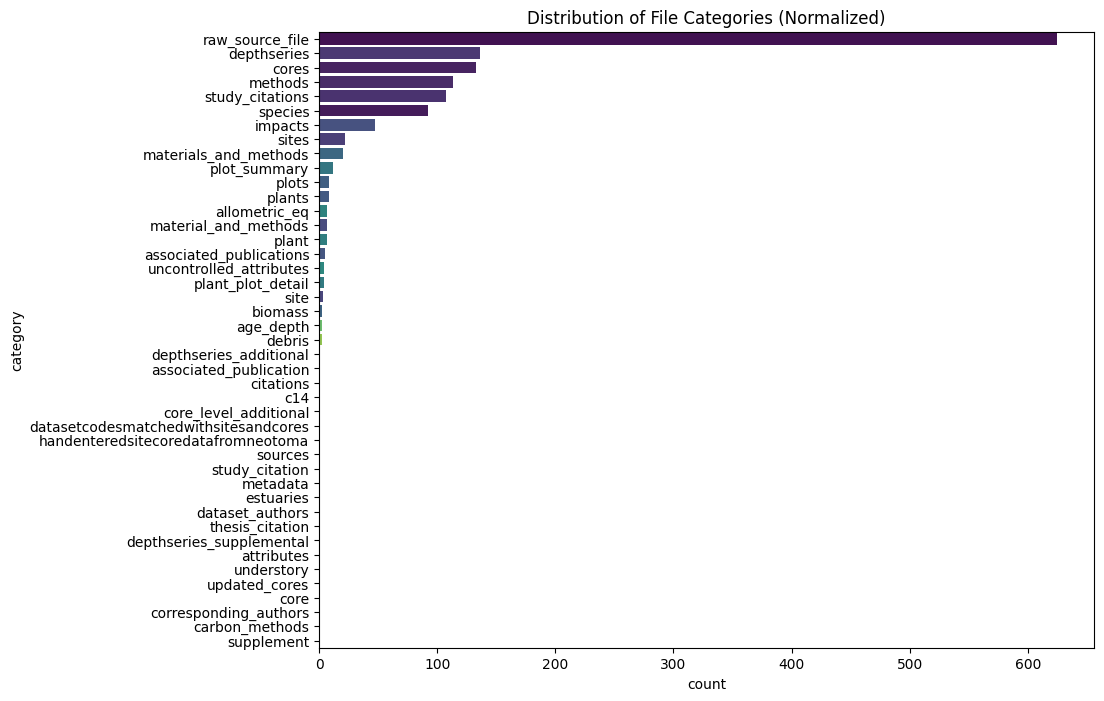

,path,filename,study_id,stage,category,ext
0,../../../data/primary_studies/Yando_2016/origi...,12_data_output_site_level_synthesis_of_all_eco...,Yando_2016,original,raw_source_file,.csv
1,../../../data/primary_studies/Yando_2016/origi...,12_data_output_site_level_synthesis_of_all_eco...,Yando_2016,original,raw_source_file,.xlsx
2,../../../data/primary_studies/Kauffman_et_al_2...,kauffman_et_al_2020_species.csv,Kauffman_et_al_2020,derivative,species,.csv
3,../../../data/primary_studies/Kauffman_et_al_2...,kauffman_et_al_2020_cores.csv,Kauffman_et_al_2020,derivative,cores,.csv
4,../../../data/primary_studies/Kauffman_et_al_2...,kauffman_et_al_2020_methods.csv,Kauffman_et_al_2020,derivative,methods,.csv


In [11]:
inventory = []
all_files = list(DATA_ROOT.rglob("*"))

print(f"Scanning {len(all_files)} total items")

for f in all_files:
    info = parse_file_info(f)
    if info:
        inventory.append(info)

df_inv = pd.DataFrame(inventory)

print(f"\nFound {len(df_inv)} valid DATA files (excluded PDFs/Bibs).")

# Breakdown by category
plt.figure(figsize=(10, 8))
order = df_inv["category"].value_counts().index
sns.countplot(y="category", data=df_inv, order=order, palette="viridis", hue="category")
plt.title("Distribution of File Categories (Normalized)")
plt.show()

display(df_inv.head())

Aggregating stats for: ['raw_source_file', 'depthseries', 'cores', 'methods']


/tmp/ipykernel_51730/3553841304.py:16: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f_path, on_bad_lines="skip")
/tmp/ipykernel_51730/3553841304.py:16: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f_path, on_bad_lines="skip")


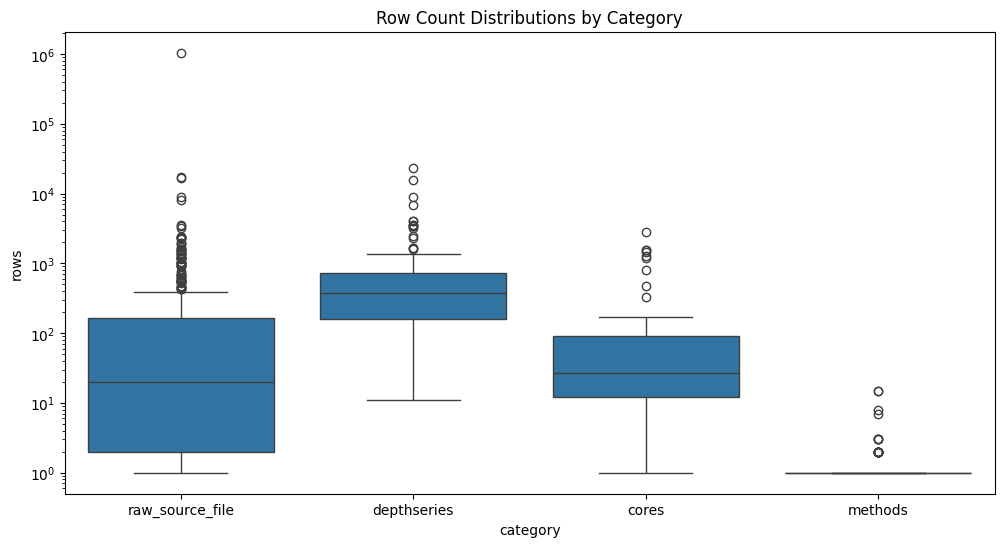

In [ ]:
# Select the most common categories
TARGET_CATEGORIES = df_inv["category"].value_counts().head(4).index.tolist()

print(f"Aggregating stats for: {TARGET_CATEGORIES}")

agg_results = []

for cat in TARGET_CATEGORIES:
    # Get all files of this type
    files = df_inv[df_inv["category"] == cat]["path"].tolist()

    for f_path in files:
        try:
            # Smart Load
            if f_path.endswith(".csv"):
                df = pd.read_csv(f_path, on_bad_lines="skip")
            else:
                df = pd.read_excel(f_path)

            # Log Metrics
            agg_results.append(
                {
                    "category": cat,
                    "rows": len(df),
                    "cols": len(df.columns),
                    "null_cells": df.isna().sum().sum(),
                    "file": Path(f_path).name,
                }
            )
        except Exception as e:
            print(f"Skipping {Path(f_path).name}: {e}")
            pass

df_stats = pd.DataFrame(agg_results)

# Row counts per category
plt.figure(figsize=(12, 6))
sns.boxplot(x="category", y="rows", data=df_stats)
plt.title("Row Count Distributions by Category")
plt.yscale("log")
plt.show()

In [ ]:
for cat in TARGET_CATEGORIES:
    # Find the largest file in this category
    cat_stats = df_stats[df_stats["category"] == cat]
    if cat_stats.empty:
        continue

    best_file_name = cat_stats.loc[cat_stats["rows"].idxmax(), "file"]
    best_file_path = df_inv[df_inv["filename"] == best_file_name]["path"].values[0]

    print(f"\n--- Report for Category: {cat.upper()} ---")
    print(f"Using representative file: {best_file_name}")

    # Generate Report
    try:
        if best_file_path.endswith(".csv"):
            df = pd.read_csv(best_file_path, on_bad_lines="skip")
        else:
            df = pd.read_excel(best_file_path)

        report = sv.analyze([df, f"Category: {cat}"])
        report.show_html(f"Report_{cat}.html")
    except Exception as e:
        print(f"Error generating report: {e}")

## Per-Category EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sweetviz as sv
import klib

# Configuration
DATA_ROOT = Path("../../../data/primary_studies")
DATA_EXTENSIONS = {".csv", ".xlsx", ".xls", ".parquet"}
STAGES = {"original", "derivative", "intermediate"}


def parse_file_info(file_path):
    path_obj = Path(file_path)
    if path_obj.suffix.lower() not in DATA_EXTENSIONS:
        return None

    try:
        parts = path_obj.relative_to(DATA_ROOT).parts
        if len(parts) != 3:
            return None
        study_id, stage = parts[0], parts[1].lower()
        if stage not in STAGES:
            return None
    except:
        return None

    clean_name = path_obj.stem
    if clean_name.lower().startswith(study_id.lower()):
        category = clean_name[len(study_id) :].lstrip("_").lower()
    else:
        category = "raw_source_file"

    return {"path": str(path_obj), "study_id": study_id, "category": category, "stage": stage}

In [ ]:
def enforce_strict_types(df):
    """
    Scans a DataFrame for mixed-type columns and fixes them.
    Remediation steps:
    1. Try converting to Numeric.
    2. If that fails (too many NaNs), force it to String.
    This resolve Sweetviz errors for conflicting types
    """
    for col in df.columns:
        # Skip if already clean
        if pd.api.types.is_numeric_dtype(df[col]):
            continue

        # Attempt numeric conversion
        numeric_series = pd.to_numeric(df[col], errors="coerce")

        # Check data loss
        original_non_nulls = df[col].count()
        new_non_nulls = numeric_series.count()

        # If we retained >80% of data as numeric, assume it's a number column with some typos
        if original_non_nulls > 0 and (new_non_nulls / original_non_nulls) > 0.8:
            df[col] = numeric_series
        else:
            # Otherwise force string to eliminate "mixed-integer" error
            df[col] = df[col].astype(str)

            # Clean up "nan" strings that result from astype(str) on nulls
            df.loc[df[col] == "nan", col] = np.nan
            df.loc[df[col] == "None", col] = np.nan

    return df


def load_and_aggregate_category(file_info_df, category_name):
    print(f"\n--- Load Data for Category: {category_name.upper()} ---")

    subset = file_info_df[file_info_df["category"] == category_name]
    files_to_load = subset["path"].tolist()
    studies = subset["study_id"].tolist()

    loaded_dfs = []

    for i, f_path in enumerate(files_to_load):
        try:
            # Load Data
            if f_path.endswith(".csv"):
                df = pd.read_csv(f_path, on_bad_lines="skip", low_memory=False)
            else:
                df = pd.read_excel(f_path)

            # Standardization
            df.columns = df.columns.str.lower().str.strip()
            df["source_study"] = studies[i]
            loaded_dfs.append(df)
        except Exception as e:
            print(f"Skipping {Path(f_path).name}: {e}")
            pass

    if not loaded_dfs:
        print("No data could be loaded.")
        return None

    # Merge data
    # Identify common columns using 30% as threshold
    all_cols = [set(d.columns) for d in loaded_dfs]
    from collections import Counter

    col_counts = Counter(c for cols in all_cols for c in cols)
    threshold = len(loaded_dfs) * 0.3
    common_cols = [c for c, count in col_counts.items() if count >= threshold]

    if "source_study" not in common_cols:
        common_cols.append("source_study")

    print(f"Aligning on {len(common_cols)} columns: {common_cols}")

    aligned_dfs = [d[[c for c in common_cols if c in d.columns]] for d in loaded_dfs]
    master_df = pd.concat(aligned_dfs, ignore_index=True)

    # Enforce types
    master_df = enforce_strict_types(master_df)

    return master_df

In [22]:
# Scan Files
all_files = list(DATA_ROOT.rglob("*"))
inventory = [parse_file_info(f) for f in all_files if parse_file_info(f)]
df_inv = pd.DataFrame(inventory)

# Using derivative files for this test run
target_df = df_inv[df_inv["stage"] == "derivative"]

# Identify Top Categories
top_cats = target_df["category"].value_counts().head(4).index.tolist()
print(f"Top Categories to Analyze: {top_cats}")

Top Categories to Analyze: ['raw_source_file', 'study_citations', 'cores', 'depthseries']



--- Load Data for Category: RAW_SOURCE_FILE ---
Aligning on 6 columns: ['method_id', 'study_id', 'source_study', 'core_id', 'site_id', 'year']

--- Analysis for category: RAW_SOURCE_FILE ---
Total Rows: 34161 | Total Columns: 6


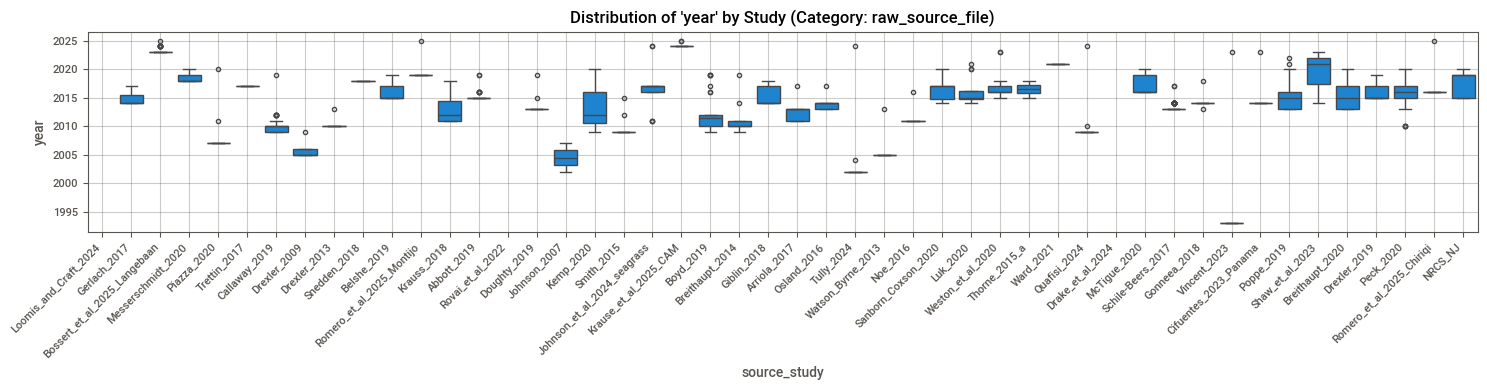

Global Correlation Matrix for raw_source_file
Generating Sweetviz report for aggregated raw_source_file data...


/home/klewtak/NASA/CCN-Data-Library/scripts/4_capstone/.venv/lib/python3.13/site-packages/klib/describe.py:389: RuntimeWarning: All-NaN axis encountered
  vmax = np.round(np.nanmax(corr.where(~mask)) - 0.05, 2)
/home/klewtak/NASA/CCN-Data-Library/scripts/4_capstone/.venv/lib/python3.13/site-packages/klib/describe.py:390: RuntimeWarning: All-NaN axis encountered
  vmin = np.round(np.nanmin(corr.where(~mask)) + 0.05, 2)


                                             |          | [  0%]   00:00 -> (? left)

Report Trend_Analysis_raw_source_file.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved to: Trend_Analysis_raw_source_file.html

--- Load Data for Category: STUDY_CITATIONS ---
Aligning on 16 columns: ['url', 'month', 'year', 'bibtype', 'publication_type', 'journal', 'study_id', 'copyright', 'bibliography_id', 'source_study', 'publisher', 'author', 'doi', 'title', 'pages', 'volume']

--- Analysis for category: STUDY_CITATIONS ---
Total Rows: 848 | Total Columns: 16


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found


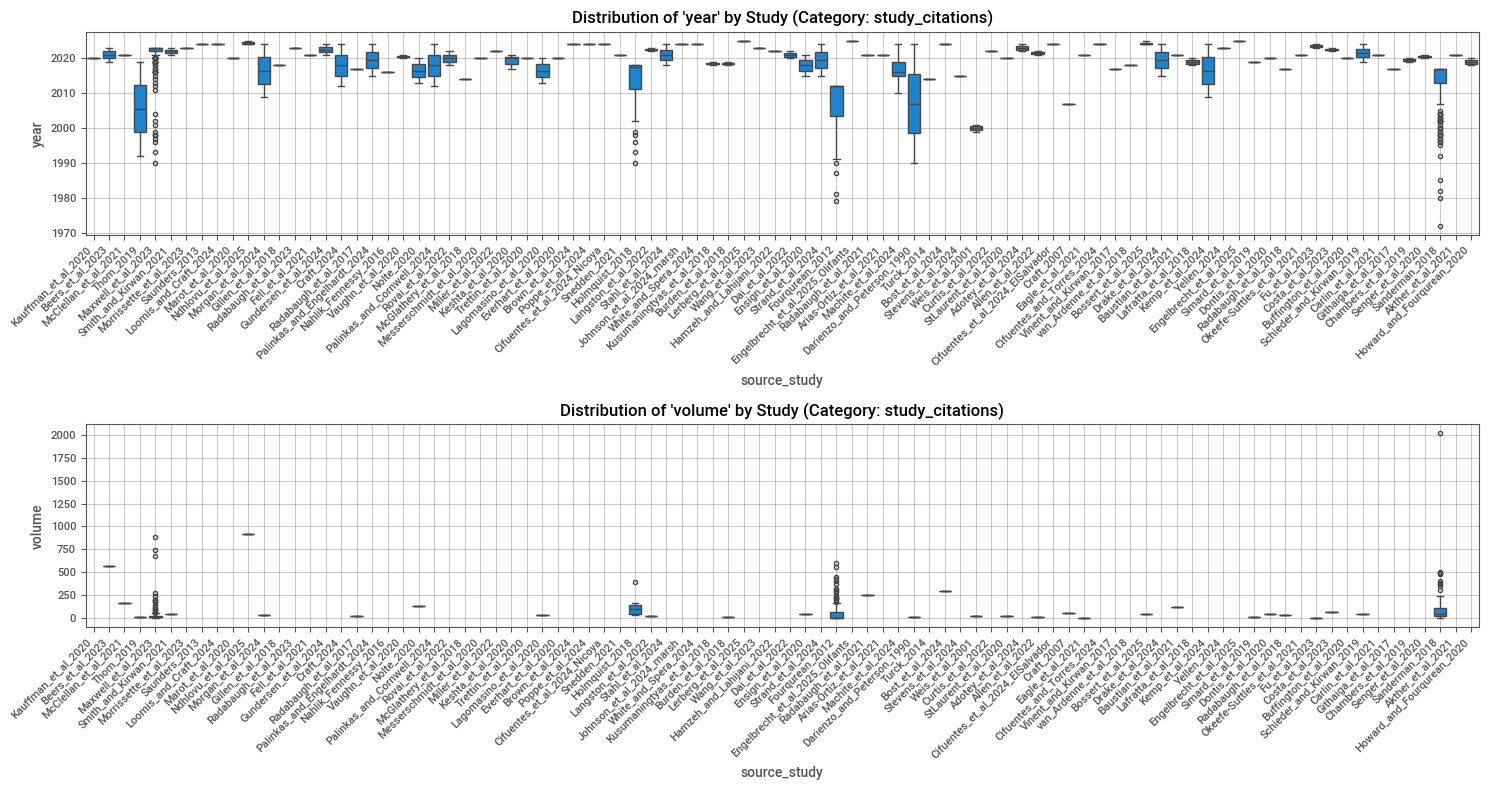

Global Correlation Matrix for study_citations
Generating Sweetviz report for aggregated study_citations data...


/usr/bin/xdg-open: 882: lynx: not found


                                             |          | [  0%]   00:00 -> (? left)

/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'file:///home/klewtak/NASA/CCN-Data-Library/scripts/4_capstone/EDA/Trend_Analysis_raw_source_file.html'


Report Trend_Analysis_study_citations.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved to: Trend_Analysis_study_citations.html

--- Load Data for Category: CORES ---
Aligning on 19 columns: ['position_notes', 'position_method', 'elevation', 'habitat', 'year', 'core_id', 'salinity_method', 'study_id', 'longitude', 'source_study', 'vegetation_class', 'salinity_class', 'latitude', 'site_id', 'vegetation_method', 'day', 'core_length_flag', 'inundation_class', 'month']

--- Analysis for category: CORES ---
Total Rows: 12108 | Total Columns: 19


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method avai

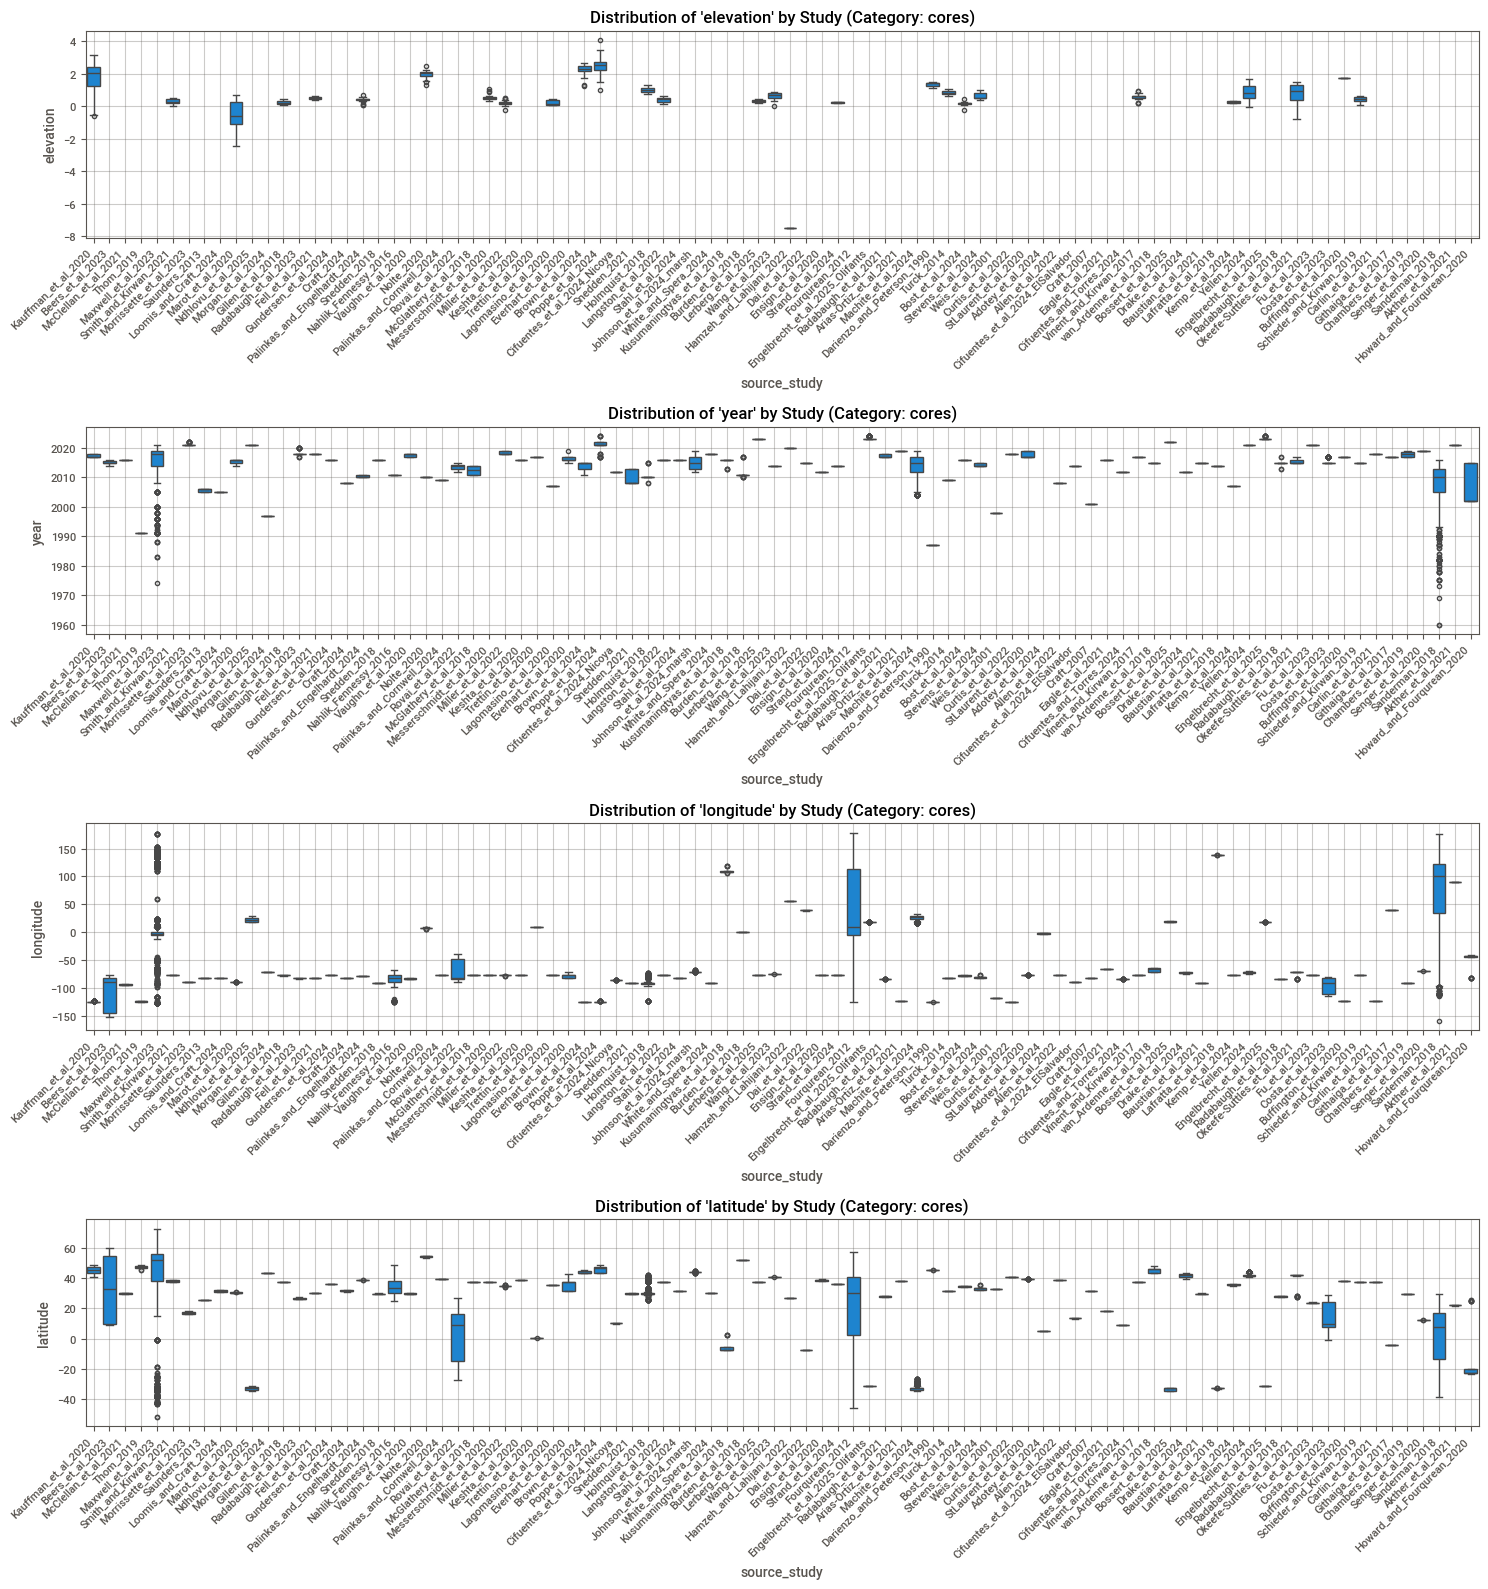

Global Correlation Matrix for cores
Generating Sweetviz report for aggregated cores data...


                                             |          | [  0%]   00:00 -> (? left)

Report Trend_Analysis_cores.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved to: Trend_Analysis_cores.html

--- Load Data for Category: DEPTHSERIES ---


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found


Aligning on 14 columns: ['method_id', 'depth_max', 'dry_bulk_density', 'core_id', 'study_id', 'source_study', 'site_id', 'depth_min', 'fraction_carbon', 'fraction_organic_matter', 'cs137_activity', 'cs137_unit', 'total_pb210_activity', 'pb210_unit']

--- Analysis for category: DEPTHSERIES ---
Total Rows: 82753 | Total Columns: 14


/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'file:///home/klewtak/NASA/CCN-Data-Library/scripts/4_capstone/EDA/Trend_Analysis_cores.html'


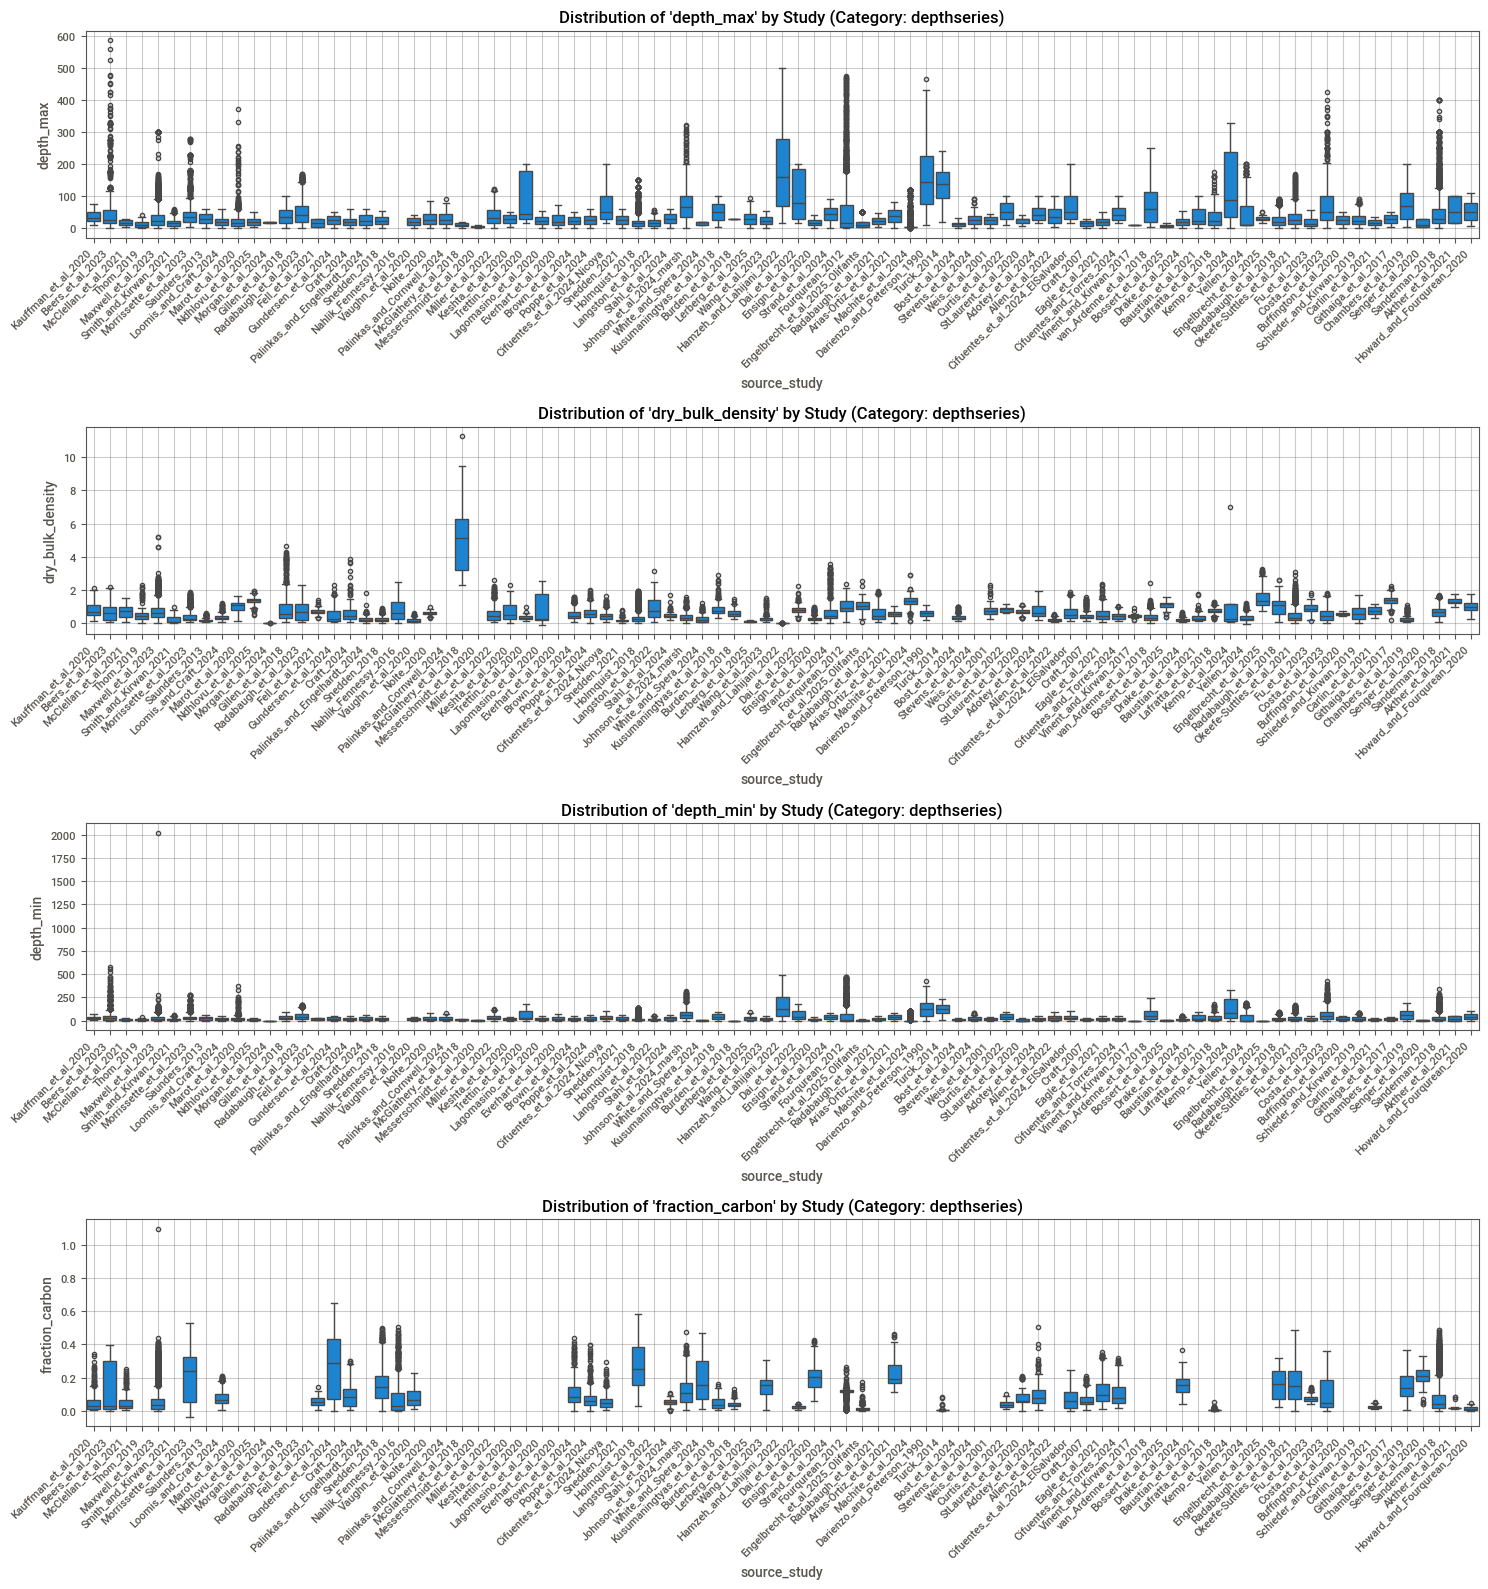

Global Correlation Matrix for depthseries
Generating Sweetviz report for aggregated depthseries data...


                                             |          | [  0%]   00:00 -> (? left)

Report Trend_Analysis_depthseries.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved to: Trend_Analysis_depthseries.html


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method avai

In [ ]:
# Numpy error fix for sweetviZ
if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = UserWarning

for cat in top_cats:
    # Aggregate data
    big_df = load_and_aggregate_category(target_df, cat)

    if big_df is None or big_df.empty:
        print(f"Skipping {cat} (Empty DataFrame)")
        continue

    # Detect numeric columns
    numeric_cols = big_df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove 'unnamed' index columns
    numeric_cols = [c for c in numeric_cols if "unnamed" not in c]

    print(f"\n--- Analysis for category: {cat.upper()} ---")
    print(f"Total Rows: {len(big_df)} | Total Columns: {len(big_df.columns)}")

    # Visualizing study comparison
    if len(numeric_cols) > 0:
        # Pick top 4 numeric metrics to plot
        cols_to_plot = numeric_cols[:4]

        plt.figure(figsize=(15, 4 * len(cols_to_plot)))
        for idx, col in enumerate(cols_to_plot):
            plt.subplot(len(cols_to_plot), 1, idx + 1)

            # Distribution of Metric X by Study
            sns.boxplot(data=big_df, x="source_study", y=col)
            plt.title(f"Distribution of '{col}' by Study (Category: {cat})")
            plt.xticks(rotation=45, ha="right")
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Correlation matrix of global trends
        print(f"Global Correlation Matrix for {cat}")
        try:
            klib.corr_plot(big_df)

        except Exception as e:
            print(f"klib failed for {cat}: {e}")
            plt.figure(figsize=(10, 8))
            sns.heatmap(big_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
            plt.title(f"Correlation Matrix - {cat}")
            plt.show()

    print(f"Generating Sweetviz report for aggregated {cat} data...")
    try:
        # Explicitly turn off pairwise analysis if it causes memory issues on big data
        report = sv.analyze([big_df, f"All {cat} Data"])
        filename = f"Trend_Analysis_{cat}.html"
        report.show_html(filename)
        print(f"Report saved to: {filename}")

    except Exception as e:
        print(f"Sweetviz failed for {cat}: {e}")